In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

In [ ]:
data = pd.read_csv('earthquake_data.csv', sep = ',')
data

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 7.0 - 18 km SW of Malango, Solomon Islands",7.0,22-11-2022 02:03,8,7,green,1,768,us,117,0.509,17.0,mww,14.000,-9.7963,159.596,"Malango, Solomon Islands",Oceania,Solomon Islands
1,"M 6.9 - 204 km SW of Bengkulu, Indonesia",6.9,18-11-2022 13:37,4,4,green,0,735,us,99,2.229,34.0,mww,25.000,-4.9559,100.738,"Bengkulu, Indonesia",NaN,NaN
2,M 7.0 -,7.0,12-11-2022 07:09,3,3,green,1,755,us,147,3.125,18.0,mww,579.000,-20.0508,-178.346,NaN,Oceania,Fiji
3,"M 7.3 - 205 km ESE of Neiafu, Tonga",7.3,11-11-2022 10:48,5,5,green,1,833,us,149,1.865,21.0,mww,37.000,-19.2918,-172.129,"Neiafu, Tonga",NaN,NaN
4,M 6.6 -,6.6,09-11-2022 10:14,0,2,green,1,670,us,131,4.998,27.0,mww,624.464,-25.5948,178.278,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,"M 7.7 - 28 km SSW of Puerto El Triunfo, El Sal...",7.7,13-01-2001 17:33,0,8,NaN,0,912,us,427,0.000,0.0,mwc,60.000,13.0490,-88.660,"Puerto El Triunfo, El Salvador",NaN,NaN
778,"M 6.9 - 47 km S of Old Harbor, Alaska",6.9,10-01-2001 16:02,5,7,NaN,0,745,ak,0,0.000,0.0,mw,36.400,56.7744,-153.281,"Old Harbor, Alaska",North America,NaN
779,"M 7.1 - 16 km NE of Port-Olry, Vanuatu",7.1,09-01-2001 16:49,0,7,NaN,0,776,us,372,0.000,0.0,mwb,103.000,-14.9280,167.170,"Port-Olry, Vanuatu",NaN,Vanuatu
780,"M 6.8 - Mindanao, Philippines",6.8,01-01-2001 08:54,0,5,NaN,0,711,us,64,0.000,0.0,mwc,33.000,6.6310,126.899,"Mindanao, Philippines",NaN,NaN


# Bagian Baru

In [ ]:
df = data.iloc[:,[1,4,5,6,13]]
df


,magnitude,mmi,alert,tsunami,depth
0,7.0,7,green,1,14.000
1,6.9,4,green,0,25.000
2,7.0,3,green,1,579.000
3,7.3,5,green,1,37.000
4,6.6,2,green,1,624.464
...,...,...,...,...,...
777,7.7,8,NaN,0,60.000
778,6.9,7,NaN,0,36.400
779,7.1,7,NaN,0,103.000
780,6.8,5,NaN,0,33.000


In [ ]:
value_counts = data['alert'].value_counts()

# Mencari nilai yang paling jarang muncul
rarest_value = value_counts.idxmin()

print("Nilai paling jarang muncul pada kolom 'alert':", rarest_value)

Nilai paling jarang muncul pada kolom 'alert': red


In [ ]:
df1 = df
df1["alert"]= df["alert"].fillna("red")
df1

<ipython-input-6-ab9c2edccfab>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["alert"]= df["alert"].fillna("red")


,magnitude,mmi,alert,tsunami,depth
0,7.0,7,green,1,14.000
1,6.9,4,green,0,25.000
2,7.0,3,green,1,579.000
3,7.3,5,green,1,37.000
4,6.6,2,green,1,624.464
...,...,...,...,...,...
777,7.7,8,red,0,60.000
778,6.9,7,red,0,36.400
779,7.1,7,red,0,103.000
780,6.8,5,red,0,33.000


In [ ]:


# Mengubah nilai pada kolom 'alert' sesuai dengan kriteria
df1['alert'] = df1['alert'].replace({'white': 1, 'green': 2, 'yellow': 3, 'orange': 4, 'red': 5})

X = df1.drop('tsunami', axis=1)  # atribut

y = df1['tsunami']  # label
s=SMOTE()
X,y=s.fit_resample(X,y)
print(df1)

     magnitude  mmi  alert  tsunami    depth
0          7.0    7      2        1   14.000
1          6.9    4      2        0   25.000
2          7.0    3      2        1  579.000
3          7.3    5      2        1   37.000
4          6.6    2      2        1  624.464
..         ...  ...    ...      ...      ...
777        7.7    8      5        0   60.000
778        6.9    7      5        0   36.400
779        7.1    7      5        0  103.000
780        6.8    5      5        0   33.000
781        7.5    7      5        0   33.000

[782 rows x 5 columns]


<ipython-input-7-bdd8b639d18a>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['alert'] = df1['alert'].replace({'white': 1, 'green': 2, 'yellow': 3, 'orange': 4, 'red': 5})


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Akurasi:", accuracy)

Akurasi: 0.8541666666666666


In [ ]:
print(confusion_matrix(y_test,y_pred))

[[39 12]
 [ 2 43]]


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.76      0.85        51
           1       0.78      0.96      0.86        45

    accuracy                           0.85        96
   macro avg       0.87      0.86      0.85        96
weighted avg       0.87      0.85      0.85        96



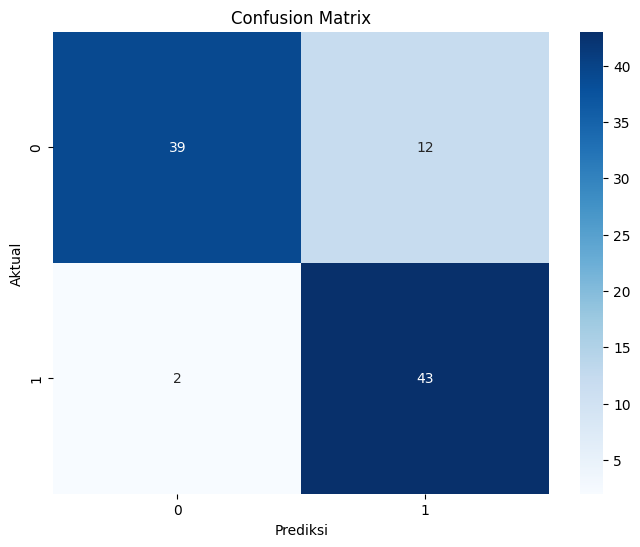

In [ ]:
cm = confusion_matrix(y_test, y_pred)

# Membuat heatmap confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

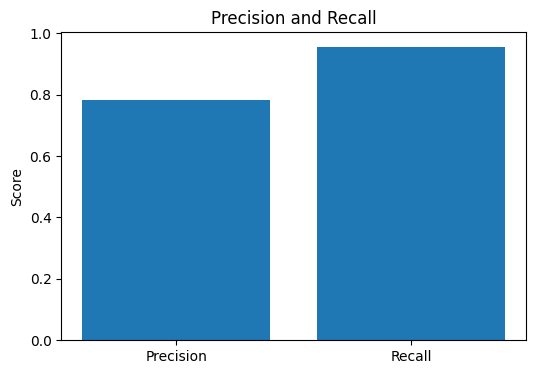

In [ ]:
y_pred = model.predict(X_test)

# Menghitung classification report
classification_rep = classification_report(y_test, y_pred, output_dict=True)

# Mendapatkan nilai precision dan recall
precision = classification_rep['1']['precision']
recall = classification_rep['1']['recall']

# Membuat bar plot precision dan recall
labels = ['Precision', 'Recall']
values = [precision, recall]

plt.figure(figsize=(6, 4))
plt.bar(labels, values)
plt.title('Precision and Recall')
plt.ylabel('Score')
plt.show()

In [ ]:

clf = GaussianNB()
clf.fit(X, y)

def prog():
    magnitude = float(input("Magnitude: "))
    alert = float(input("Alert: "))
    keadalaman = float(input("Kedalaman: "))
    mmi = float(input("MMI: "))

    prediction = clf.predict([[magnitude, alert, keadalaman, mmi]])
    if prediction == 1:
        print("\nTsunami: Ya")
    else:
        print("\nTsunami: Tidak")

prog()

Magnitude: 6.6
Alert: 3
Kedalaman: 23000
MMI: 4

Tsunami: Tidak


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
